In [8]:
from sentinel import Sentinel

import os
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
ClientID = os.getenv('SH_CLIENT_ID')
ClientSecret = os.getenv('SH_CLIENT_SECRET')

sentinel = Sentinel(client_id = ClientID, client_secret = ClientSecret)

sentinel.set_aoi(36.220030,54.504157,36.236213,54.512579) # http://bboxfinder.com/
sentinel.set_resolution(10)

sentinel.set_date(date = '2025-08-24', num_days_back = 22)
sentinel.time_interval

('2025-08-02', '2025-08-24')

In [6]:
sentinel.set_date(date = 'latest')
sentinel.time_interval

('2025-09-29', '2025-10-06')

## Чтобы узнать какие слои доступны в sentinel.py смотри LAYER_DEFINITIONS 

Все каналы, представленные на изображении, являются частью данных, получаемых со спутников Sentinel-2 в рамках европейской программы Copernicus. Эти спутники оснащены мультиспектральным сканером (MSI), который фиксирует отраженное от Земли излучение в 13 спектральных диапазонах. Ниже приведено подробное описание каждого из этих каналов.

### Спектральные каналы (Bands)

Каждый спектральный канал предназначен для фиксации определенной части электромагнитного спектра, что позволяет решать разнообразные задачи, от мониторинга растительности до анализа атмосферных явлений.

*   **B01 (Прибрежные аэрозоли):** Используется для изучения аэрозолей и прибрежных зон.
*   **B02 (Синий):** Применяется для различения почвы и растительности, картографирования лесов и искусственных объектов. Также полезен для батиметрии (измерения глубины) в чистой воде.
*   **B03 (Зеленый):** Обеспечивает хороший контраст между чистой и мутной водой, помогает выделять нефтяные пятна на поверхности воды и растительность. Используется для оценки состояния растительности.
*   **B04 (Красный):** Эффективен для определения типов растительности, почв и городских территорий. Этот канал чувствителен к поглощению хлорофиллом.
*   **B05, B06, B07 (Красный край):** Эти каналы особенно важны для классификации и мониторинга состояния растительности.
*   **B08 (Ближний инфракрасный - NIR):** Хорошо подходит для картографирования береговых линий, оценки биомассы и анализа растительности.
*   **B8A (Узкий ближний инфракрасный - Narrow NIR):** Также используется для анализа растительности.
*   **B09 (Водяной пар):** Применяется для оценки содержания водяного пара в атмосфере.
*   **B11, B12 (Коротковолновый инфракрасный - SWIR):** Эти каналы полезны для измерения влажности почвы и растительности, а также для различения снега и облаков.

### Дополнительные каналы и метаданные

Помимо основных спектральных каналов, спутниковые данные Sentinel-2 включают в себя ряд вспомогательных слоев и метаданных, которые помогают в их обработке и анализе.

*   **AOT (Aerosol Optical Thickness - Аэрозольная оптическая толщина):** Карта, показывающая степень замутненности атмосферы аэрозолями.
*   **SCL (Scene Classification Layer - Слой классификации сцены):** Карта, на которой каждый пиксель классифицирован как один из типов поверхности (например, растительность, вода, облака, снег и т.д.).
*   **CLD (Cloud Probability - Вероятность облачности):** Карта, отображающая вероятность наличия облаков.
*   **CLP (Cloud Probability - Вероятность облачности):** Альтернативная карта вероятности облачности, рассчитанная по другому алгоритму.
*   **SNW (Snow Probability - Вероятность снега):** Карта, показывающая вероятность наличия снежного покрова.
*   **CLM (Cloud Masks - Маски облачности):** Двоичная маска, указывающая на наличие или отсутствие облаков.
*   **sunAzimuthAngles (Азимутальный угол Солнца):** Азимутальный угол Солнца в градусах.
*   **sunZenithAngles (Зенитный угол Солнца):** Зенитный угол Солнца в градусах.
*   **viewAzimuthMean (Средний азимутальный угол обзора):** Средний азимутальный угол сенсора спутника.
*   **viewZenithMean (Средний зенитный угол обзора):** Средний зенитный угол сенсора спутника.
*   **dataMask (Маска данных):** Маска, которая указывает на наличие или отсутствие данных для каждого пикселя.

In [7]:
data = sentinel.get_data(['true_color'])
plt.imshow(data)

ValueError: Configuration parameters 'sh_client_id' and 'sh_client_secret' have to be set in order to authenticate with Sentinel Hub service. Check https://sentinelhub-py.readthedocs.io/en/latest/configure.html for more info.

In [19]:
data = sentinel.get_data(['ndvi'])
data

array([[-0.16666667, -0.19101124, -0.22178988, ...,  0.6999552 ,
         0.7412619 ,  0.8055556 ],
       [-0.20149253, -0.17777778, -0.22891566, ...,  0.58649206,
         0.75359815,  0.72738856],
       [-0.2818533 , -0.2981132 , -0.30038023, ...,  0.27102804,
         0.4159544 ,  0.24074075],
       ...,
       [ 0.8649539 ,  0.8595342 ,  0.8562614 , ...,  0.8790036 ,
         0.8887484 ,  0.8887484 ],
       [ 0.87483954,  0.84390247,  0.8370905 , ...,  0.79501134,
         0.79501134,  0.8557377 ],
       [ 0.8561249 ,  0.86027944,  0.8716502 , ...,  0.83272725,
         0.7901991 ,  0.82750714]], shape=(90, 108), dtype=float32)

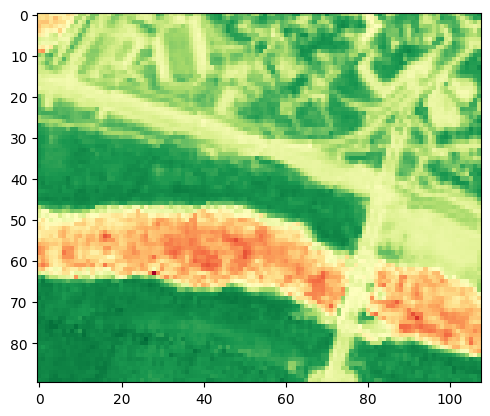

In [11]:
plt.imshow(data, cmap = 'RdYlGn')

In [12]:
data = sentinel.get_data(['ndvi', 'dataMask'])
data

{'ndvi.tif': array([[-0.16666667, -0.19101124, -0.22178988, ...,  0.6999552 ,
          0.7412619 ,  0.8055556 ],
        [-0.20149253, -0.17777778, -0.22891566, ...,  0.58649206,
          0.75359815,  0.72738856],
        [-0.2818533 , -0.2981132 , -0.30038023, ...,  0.27102804,
          0.4159544 ,  0.24074075],
        ...,
        [ 0.8649539 ,  0.8595342 ,  0.8562614 , ...,  0.8790036 ,
          0.8887484 ,  0.8887484 ],
        [ 0.87483954,  0.84390247,  0.8370905 , ...,  0.79501134,
          0.79501134,  0.8557377 ],
        [ 0.8561249 ,  0.86027944,  0.8716502 , ...,  0.83272725,
          0.7901991 ,  0.82750714]], shape=(90, 108), dtype=float32),
 'dataMask.tif': array([[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]], shape=(90, 108), dtype=uint8)}

Канал `dataMask` в данных Sentinel-2 представляет собой вспомогательный слой, который указывает на наличие или отсутствие данных в каждом конкретном пикселе. Это бинарная маска, где пиксели могут иметь только два значения:

*   **1:** Означает, что для этого пикселя существуют действительные данные со спутника.
*   **0:** Означает, что данные для этого пикселя отсутствуют ("no data").

### Для чего нужны пиксели "no data"?

Пиксели со значением "no data" появляются по нескольким причинам:

*   **Края области съемки:** Спутниковые снимки (сцены) имеют определенные границы. Пиксели, находящиеся за пределами этих границ, не содержат информации.
*   **Запрошенная область интереса:** Если вы запрашиваете данные для определенной географической области (например, по контуру поля или административного района), пиксели за пределами этой области будут помечены как "no data".
*   **Отсутствие исходных данных:** В редких случаях в исходных данных могут быть пробелы из-за ошибок при передаче или обработке.

### Основные цели использования `dataMask`

Использование `dataMask` является важным шагом в предварительной обработке спутниковых снимков для обеспечения точности анализа. Вот его основные применения:

1.  **Исключение неинформативных пикселей из анализа:** Это наиболее важное применение. При расчете различных индексов (например, вегетационного индекса NDVI), статистических показателей или при обучении моделей машинного обучения, пиксели без данных могут исказить результаты. Применение маски позволяет проводить вычисления только по тем пикселям, которые содержат реальные измерения.

2.  **Визуализация:** `dataMask` позволяет сделать области без данных прозрачными на итоговом изображении. Это улучшает визуальное восприятие и помогает сосредоточиться на интересующей территории. Например, при создании композитного изображения из нескольких снимков, `dataMask` помогает "спрятать" черные поля по краям и создать бесшовное изображение.

3.  **Присвоение пользовательских значений:** В некоторых случаях аналитики могут захотеть присвоить пикселям без данных определенное значение (например, -9999), чтобы их было легко идентифицировать и отфильтровать на последующих этапах обработки.

Таким образом, `dataMask` — это фундаментальный инструмент для контроля качества данных, который позволяет отделить полезную информацию от пустых областей на снимке, обеспечивая тем самым корректность и точность дальнейшего анализа и визуализации.

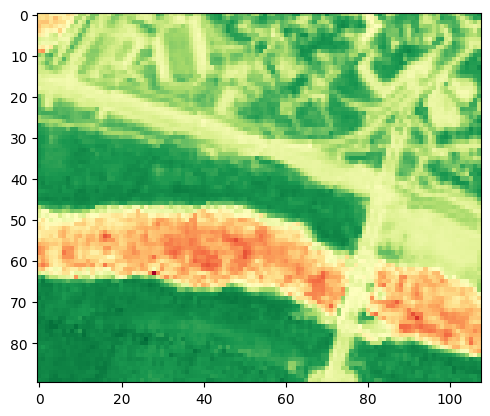

In [14]:
plt.imshow(data['ndvi.tif'], cmap = 'RdYlGn', alpha = data['dataMask.tif'])

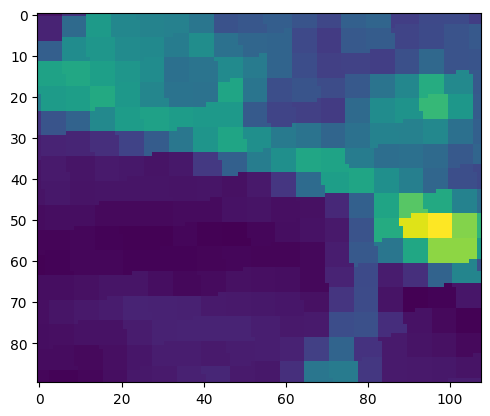

In [5]:
data = sentinel.get_data(['B01'])
plt.imshow(data)